In [28]:
import torch
from torch import nn
from torchsummary import summary
import torch.utils.data as Data
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
from torchvision.datasets import FashionMNIST
import copy,time


In [29]:
# 数据集构建
full_data = FashionMNIST(root='./data',train=True,transform=transforms.Compose([transforms.Resize(size=28),transforms.ToTensor()]),download=True)
train_data,val_data = Data.random_split(dataset=full_data,lengths=[round(0.8*len(full_data)),round(0.2*len(full_data))])
train_loader = Data.DataLoader(dataset=train_data,batch_size=128,shuffle=True,num_workers=0)
val_loader = Data.DataLoader(dataset=val_data,batch_size=128,shuffle=False,num_workers=0)
# 获得一个batch的数据
i=1
for batch_idx,(data,target) in enumerate(train_loader):
    if i>0:
      print(data.shape)
      print(target.shape)
      i-=1
    if batch_idx > 0:
      break
batch_x = data.squeeze().numpy()#将四维张亮去掉第一维
batch_y=target.numpy()
class_label = train_data.dataset.classes#训练集的类别标签
# 打印数据形状    
print(batch_x.shape)
print(batch_y.shape)
print(class_label)


torch.Size([128, 1, 28, 28])
torch.Size([128])
(128, 28, 28)
(128,)
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [30]:
# 模型搭建
class LetNet(nn.Module):
    def __init__(self):
        super(LetNet, self).__init__()
        self.c1 = nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5,padding=2)
        self.sig = nn.Sigmoid()
        self.s2 = nn.AvgPool2d(kernel_size=2,stride=2)
        self.c3 = nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5)
        self.s4 = nn.AvgPool2d(kernel_size=2,stride=2)
        self.flatten = nn.Flatten()
        self.l5 = nn.Linear(16*5*5,120)
        self.l6 = nn.Linear(120,84)
        self.l7 = nn.Linear(84,10)
    def forward(self,x):
        x = self.sig(self.c1(x))
        x = self.s2(x)
        x=self.sig(self.c3(x))
        x =self.s4(x)
        x = self.flatten(x)
        x = self.l5(x)
        x = self.l6(x)
        x = self.l7(x)
        return x

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LetNet().to(device)
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
           Sigmoid-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
           Sigmoid-5           [-1, 16, 10, 10]               0
         AvgPool2d-6             [-1, 16, 5, 5]               0
           Flatten-7                  [-1, 400]               0
            Linear-8                  [-1, 120]          48,120
            Linear-9                   [-1, 84]          10,164
           Linear-10                   [-1, 10]             850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.11
Params size (MB): 0.24
Estimated Tot

In [31]:
# 定义优化器和损失函数
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
criterion =nn.CrossEntropyLoss()#交叉熵用于分类


In [32]:
import pandas as pd
import copy
import torch
from torch.nn.modules import loss
from tqdm import tqdm 
import time

# 训练
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_loss_all = []
val_loss_all = []
train_acc_all = []
val_acc_all = []
epoch_num = 20

for epoch in range(epoch_num):
    # 初始化每一轮的参数
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0
    train_num = 0
    val_num = 0
    
    # =================  使用 tqdm 包裹 train_loader =================
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epoch_num-1}', unit='batch')
    # 注意：这里循环的是 train_bar，而不是原来的 train_loader
    for step, (b_x, b_y) in enumerate(train_bar):
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        model.train()
        optimizer.zero_grad()
        output = model(b_x)
        pre_label = torch.argmax(output, 1)
        loss = criterion(output, b_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * b_x.size(0)
        train_acc += torch.sum(pre_label == b_y.data)
        train_num += b_x.size(0)

        # ================= 修改点 2: 实时更新进度条右侧的显示 =================
        # set_postfix 可以显示当前 Batch 的 Loss，让你知道模型是不是在收敛
        train_bar.set_postfix(loss=loss.item())

    # 验证循环 (通常验证很快，也可以加 tqdm，或者保持原样)
    for step, (b_x, b_y) in enumerate(val_loader):
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        model.eval()
        # 验证阶段记得加上 no_grad，省显存
        with torch.no_grad():
            output = model(b_x)
            pre_label = torch.argmax(output, 1)
            loss = criterion(output, b_y)
            val_loss += loss.item() * b_x.size(0)
            val_acc += torch.sum(pre_label == b_y.data)
            val_num += b_x.size(0)

    train_loss_all.append(train_loss / train_num)
    train_acc_all.append(train_acc.double() / train_num)
    val_loss_all.append(val_loss / val_num)
    val_acc_all.append(val_acc.double() / val_num)

    # 深度拷贝模型
    if val_acc_all[-1] > best_acc:
        best_acc = val_acc_all[-1]
        best_model_wts = copy.deepcopy(model.state_dict())
    # 每10个epoch打印一次结果
    if epoch % 10 == 0:
        # tqdm.write 是专门用来在进度条存在时安全打印的方法
        tqdm.write(f"Epoch {epoch} summary:") 
        tqdm.write(f"  Train Loss: {train_loss_all[-1]:.4f} Acc: {train_acc_all[-1]:.4f}")
        tqdm.write(f"  Val   Loss: {val_loss_all[-1]:.4f} Acc: {val_acc_all[-1]:.4f}")

# 保存模型
torch.save(best_model_wts, 'best_model.pth')

# 数据转换处理
train_process = pd.DataFrame(data={
    "epoch": range(epoch_num),
    "train_loss": train_loss_all,
    "val_loss": val_loss_all,
    "train_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in train_acc_all],
    "val_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in val_acc_all]
})
print("Training Complete. Data saved.")

Epoch 0/19: 100%|██████████| 375/375 [00:11<00:00, 33.76batch/s, loss=0.678]


Epoch 0 summary:
  Train Loss: 1.2230 Acc: 0.5346
  Val   Loss: 0.7551 Acc: 0.7107


Epoch 10/19: 100%|██████████| 375/375 [00:11<00:00, 32.82batch/s, loss=0.42] 


Epoch 10 summary:
  Train Loss: 0.4329 Acc: 0.8449
  Val   Loss: 0.4184 Acc: 0.8486


Epoch 19/19: 100%|██████████| 375/375 [00:12<00:00, 30.16batch/s, loss=0.365]


Training Complete. Data saved.


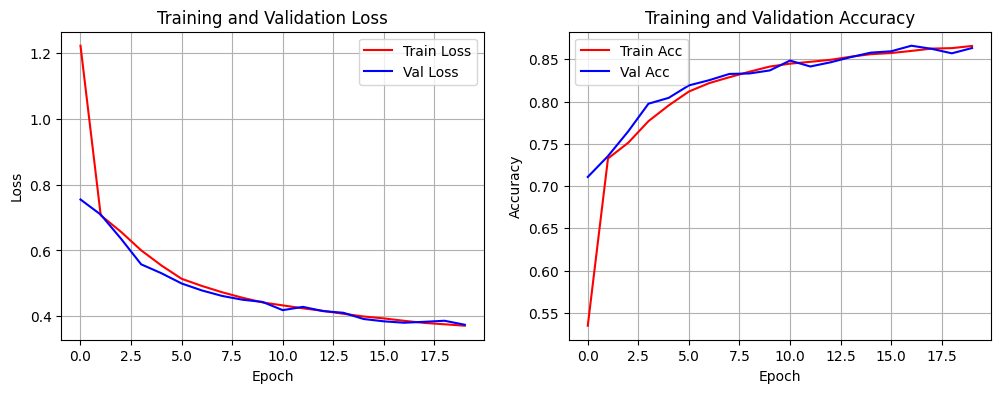

In [34]:
# ==========================================
# 3. 开始画图 (Matplotlib)
# ==========================================
plt.figure(figsize=(12, 4)) # 设置画布大小：宽12，高4

# --- 第一张图：Loss (损失率) ---
plt.subplot(1, 2, 1) # 1行2列，第1张图
plt.plot(train_process['epoch'], train_process['train_loss'], 'r', label='Train Loss') # 红线
plt.plot(train_process['epoch'], train_process['val_loss'], 'b', label='Val Loss')   # 蓝线
plt.legend() # 显示图例
plt.grid(True) # 显示网格
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

# --- 第二张图：Accuracy (准确率) ---
plt.subplot(1, 2, 2) # 1行2列，第2张图
plt.plot(train_process['epoch'], train_process['train_acc'], 'r', label='Train Acc')
plt.plot(train_process['epoch'], train_process['val_acc'], 'b', label='Val Acc')
plt.legend()
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

# 显示图表
plt.show()
